1. Imports

In [5]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features_path = r"C:\Users\dell\food-outbreak-severity-ml\src\features"

if features_path not in sys.path:
    sys.path.insert(0, features_path)

# 3. Import the file directly
import build_features

run_feature_engineering = build_features.run_feature_engineering

print("imported successfully")

imported successfully


2. Load Cleaned Data

In [6]:
df = pd.read_csv("../data/processed/outbreaks_cleaned.csv")
print(df.shape)
df.head(3)

(18745, 12)


,Year,State,Location,Status,Illnesses,Severity,Severity_code,Species_Risk,food_known,Food_Category,Month_num,Season
0,1998,California,Restaurant,Unknown,20,Moderate,1,Unknown,0,Unknown,1,Winter
1,1998,California,Unknown,Unknown,112,High,2,Unknown,1,Eggs_Dairy,1,Winter
2,1998,California,Restaurant,Unknown,35,High,2,Unknown,0,Unknown,1,Winter


3. Run Feature Engineering

In [7]:
df_featured = run_feature_engineering(df)

STARTING FEATURE ENGINEERING
illnesses_log — min: 1.10, max: 7.57

location_risk distribution:
location_risk
1     2142
2     2912
3    11308
4     2004
5      379
Name: count, dtype: int64

is_peak_month — peak: 8787, non-peak: 9958

species_x_location — unique combinations: 90

state_outbreak_rate — min: 0.000, max: 1.000

FEATURE ENGINEERING COMPLETE — Final shape: (18745, 17)
New columns added: illnesses_log, location_risk, is_peak_month, species_x_location, state_outbreak_rate


4. Verify New Features

In [8]:
new_cols = ["illnesses_log", "location_risk", "is_peak_month",
            "species_x_location", "state_outbreak_rate"]
df_featured[new_cols].describe().round(3)

,illnesses_log,location_risk,is_peak_month,state_outbreak_rate
count,18745.000,18745.000,18745.000,18745.000
mean,2.351,2.763,0.469,0.431
std,1.023,0.863,0.499,0.340
min,1.099,1.000,0.000,0.000
25%,1.386,2.000,0.000,0.150
50%,2.197,3.000,0.000,0.354
75%,3.045,3.000,1.000,0.525
max,7.570,5.000,1.000,1.000


5. Correlation of New Features with Severity

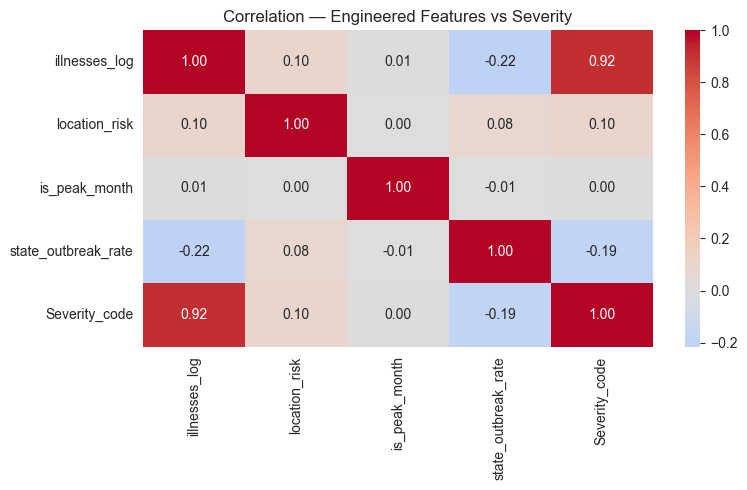

Plot saved.


In [9]:
corr_cols = ["illnesses_log", "location_risk", "is_peak_month",
             "state_outbreak_rate", "Severity_code"]

corr = df_featured[corr_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation — Engineered Features vs Severity")
plt.tight_layout()
plt.savefig("../reports/figures/04_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

6. illnesses_log Distribution

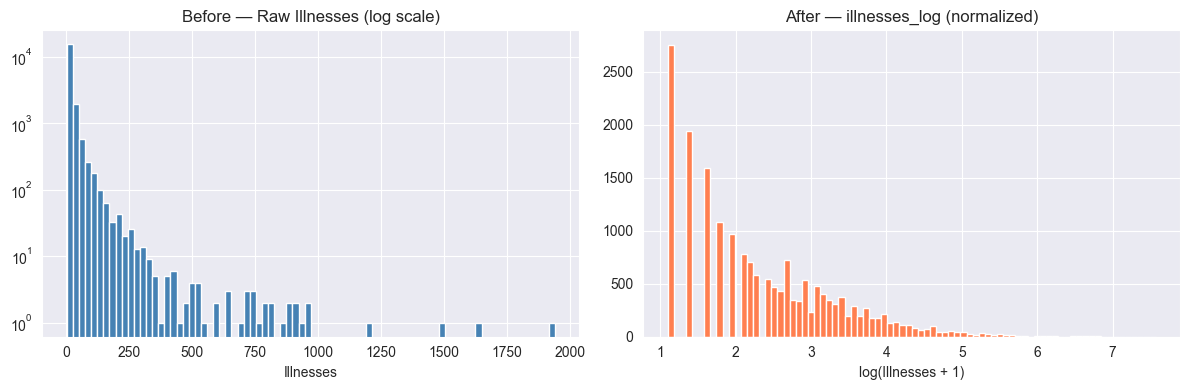

Plot saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_featured["Illnesses"], bins=80, color="steelblue", edgecolor="white", log=True)
axes[0].set_title("Before — Raw Illnesses (log scale)")
axes[0].set_xlabel("Illnesses")

axes[1].hist(df_featured["illnesses_log"], bins=80, color="coral", edgecolor="white")
axes[1].set_title("After — illnesses_log (normalized)")
axes[1].set_xlabel("log(Illnesses + 1)")

plt.tight_layout()
plt.savefig("../reports/figures/04_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

7. Save Featured Data

In [11]:
df_featured.to_csv("../data/processed/outbreaks_featured.csv", index=False)
print("Saved → data/processed/outbreaks_featured.csv")
print(f"Shape: {df_featured.shape}")
print(f"Columns: {list(df_featured.columns)}")

Saved → data/processed/outbreaks_featured.csv
Shape: (18745, 17)
Columns: ['Year', 'State', 'Location', 'Status', 'Illnesses', 'Severity', 'Severity_code', 'Species_Risk', 'food_known', 'Food_Category', 'Month_num', 'Season', 'illnesses_log', 'location_risk', 'is_peak_month', 'species_x_location', 'state_outbreak_rate']
